<a href="https://colab.research.google.com/github/Munjiwon/SpecialTopics-in-TextMining/blob/master/ch03/embedding_vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3주차 실습 4 — 임베딩 시각화(PCA · t-SNE)

**이 노트북의 새 개념**: 고차원 벡터를 2차원에 그려 군집을 본다. t-SNE 는 국소 구조만 보존하므로 **군집 사이 거리는 해석하지 않는다**.

In [1]:
%pip install -q gensim kiwipiepy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 MB 10.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 102.4 MB/s eta 0:00:00


In [2]:
import sys, torch
print("Python", sys.version.split()[0], "| torch", torch.__version__, "| GPU:", torch.cuda.is_available())

Python 3.13.15 | torch 2.11.0+cpu | GPU: False


In [3]:
# 말뭉치 준비와 형태소 토큰화 — 1주차와 같은 Steam 리뷰 감성 말뭉치("레이블<TAB>텍스트")를 내려받고,
# 단어 임베딩 학습에는 문장만 쓰므로(레이블은 따로 보관만 한다) 한국어는 형태소 단위로 나눈다(2주차에서 본 것처럼 형태소 단위가 유리하다).
STEAM_URL = "https://raw.githubusercontent.com/bab2min/corpus/master/sentiment/steam.txt"
CORPUS_PATH = "data/steam.txt"  # code03/data/ 에 저장 (노트북 위치 기준 상대경로)
USE_OWN_CORPUS = False
if USE_OWN_CORPUS:
    from google.colab import files
    uploaded = files.upload()
    CORPUS_PATH = "/content/" + next(iter(uploaded))
else:
    import os, urllib.request
    os.makedirs(os.path.dirname(CORPUS_PATH), exist_ok=True)
    if not os.path.exists(CORPUS_PATH):  # 이미 내려받았으면 건너뜀
        urllib.request.urlretrieve(STEAM_URL, CORPUS_PATH)

# 파일 형식: 한 줄에 리뷰 하나, "레이블(0=부정, 1=긍정)<TAB>리뷰 문장"
lines, labels = [], []
with open(CORPUS_PATH, encoding="utf-8") as f:
    for line in f:
        label, text = line.rstrip("\n").split("\t", 1)   # 첫 탭을 기준으로 두 칸으로 나눔
        if text.strip():
            labels.append(int(label))
            lines.append(text.strip())
print(f"리뷰 {len(lines):,}개 (부정 {labels.count(0):,} / 긍정 {labels.count(1):,})")

from kiwipiepy import Kiwi
kiwi = Kiwi()
# 문장(줄) 하나를 토큰 목록 하나로 — gensim 과 직접 구현 모두 이 형태를 쓴다
sentences = [[t.form for t in kiwi.tokenize(l)] for l in lines]
print(f"문장 {len(sentences):,}개, 토큰 {sum(map(len, sentences)):,}개")

리뷰 100,000개 (부정 50,004 / 긍정 49,996)
문장 100,000개, 토큰 2,548,479개


In [4]:
from gensim.models import Word2Vec
model = Word2Vec(sentences, sg=1, vector_size=100, window=5, min_count=3, epochs=10, seed=42, workers=1)
nouns = {t.form for l in lines for t in kiwi.tokenize(l) if t.tag == "NNG" and len(t.form) > 1}
words = [w for w in model.wv.index_to_key if w in nouns][:150]      # 자주 나오는 일반명사 150개
X = model.wv[words]
print("벡터 행렬:", X.shape)

벡터 행렬: (150, 100)


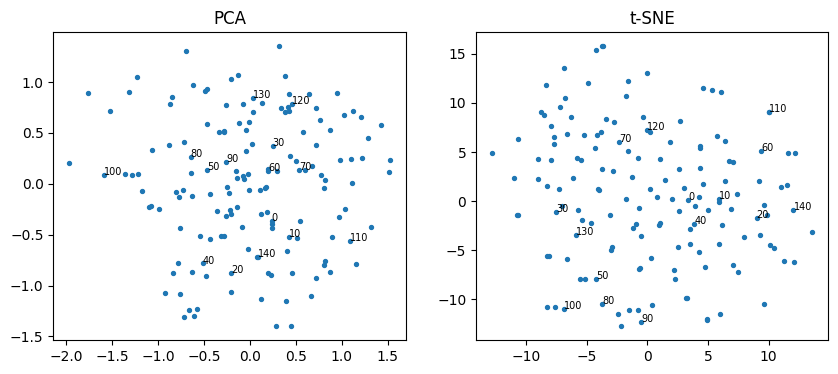

번호 → 단어: {0: '게임', 10: '정말', 20: '갓겜', 30: '엔딩', 40: '지금', 50: '문제', 60: '가지', 70: '부족', 80: '최적', 90: '추가', 100: '고치', 110: '장점', 120: '무기', 130: '중간', 140: '인생'}


In [5]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

P = PCA(n_components=2, random_state=0).fit_transform(X)
T = TSNE(n_components=2, perplexity=20, random_state=0, init="pca").fit_transform(X)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, Z, name in [(ax[0], P, "PCA"), (ax[1], T, "t-SNE")]:
    a.scatter(Z[:, 0], Z[:, 1], s=8)
    for i in range(0, len(words), 10):          # 라벨은 10개마다 하나만(겹침 방지)
        a.annotate(str(i), Z[i], fontsize=7)
    a.set_title(name)
plt.show()
print("번호 → 단어:", {i: words[i] for i in range(0, len(words), 10)})

## 직접 해 보기
1. t-SNE 의 perplexity 를 5 와 50 으로 바꾸면 그림이 어떻게 달라지는가? 같은 데이터인데 모양이 바뀌는 이유는?
2. PCA 의 첫 두 성분이 설명하는 분산 비율(`explained_variance_ratio_`)은 얼마인가?